In [20]:
# In this initial step, we initialize our data analytics environment by importing the **pandas** library.
# We then ingest the raw warehouse transactional database (`shipping_data.xlsx`) into a pandas DataFrame.
# This establishes the structural foundation for our data manipulation and operations optimization pipeline.

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('shipping_data.xlsx')
print(df.head())


  Product_ID:              Product_Name  Unit_Cost:  Quantity_Sold:  \
0      SKU001  Premium Forklift Battery        1200              15   
1      SKU002     Industrial Steel Rack         450              40   
2      SKU003    Heavy Duty Pallet Jack         300              25   
3      SKU004    Standard Wooden Pallet          15            1200   
4      SKU005     Cardboard Box - Large           2            5000   

   Current_Location  
0               NaN  
1               NaN  
2               NaN  
3               NaN  
4               NaN  


In [21]:
# To evaluate the true financial velocity of our warehouse stock, we cannot rely on unit costs or quantity sold in isolation. 
# This step executes a row-by-row matrix multiplication of the unit price and total quantity sold. 
# The resulting metric is engineered into a brand new feature called `Total_Revenue`, representing the total cash flow impact of each SKU.

df['Total_Revenue'] = df['Unit_Cost:'] * df['Quantity_Sold:']

print(df.head())

  Product_ID:              Product_Name  Unit_Cost:  Quantity_Sold:  \
0      SKU001  Premium Forklift Battery        1200              15   
1      SKU002     Industrial Steel Rack         450              40   
2      SKU003    Heavy Duty Pallet Jack         300              25   
3      SKU004    Standard Wooden Pallet          15            1200   
4      SKU005     Cardboard Box - Large           2            5000   

   Current_Location  Total_Revenue  
0               NaN          18000  
1               NaN          18000  
2               NaN           7500  
3               NaN          18000  
4               NaN          10000  


In [22]:
# An ABC inventory analysis relies on the **Pareto Principle (the 80/20 Rule)**, which states that roughly 80% of revenue comes from 20% of products. 
# To isolate these high-velocity items, we programmatically sort the entire dataset by `Total_Revenue` in descending order. 
# Once ranked, we apply a cumulative sum function (`.cumsum()`) to track the running cash flow total down the inventory list.

df = df.sort_values(by='Total_Revenue', ascending=False)
df['Cumm_Revenue'] = df['Total_Revenue'].cumsum()
print(df.head())


   Product_ID:              Product_Name  Unit_Cost:  Quantity_Sold:  \
0       SKU001  Premium Forklift Battery        1200              15   
1       SKU002     Industrial Steel Rack         450              40   
3       SKU004    Standard Wooden Pallet          15            1200   
7       SKU008       LED Warehouse Light          85             150   
12      SKU013    Shipping Labels (Roll)           8            1500   

    Current_Location  Total_Revenue  Cumm_Revenue  
0                NaN          18000         18000  
1                NaN          18000         36000  
3                NaN          18000         54000  
7                NaN          12750         66750  
12               NaN          12000         78750  


In [23]:
# Here, we convert our raw cumulative revenue dollars into a standardized decimal percentage by dividing each row by the warehouse's grand total revenue. Using these percentages, we deploy the `pd.cut()` function to bucket our stock into three strict operational classes:
# * **Class A (Top 80% of Revenue)**: High-value items requiring strict stock controls.
# * **Class B (Next 15% of Revenue)**: Medium-value items needing standard oversight.
# * **Class C (Bottom 5% of Revenue)**: Low-value, slow-moving stock.

df['Cumm_Percentage'] = df['Cumm_Revenue'] / df['Total_Revenue'].sum()
print(df.head())

   Product_ID:              Product_Name  Unit_Cost:  Quantity_Sold:  \
0       SKU001  Premium Forklift Battery        1200              15   
1       SKU002     Industrial Steel Rack         450              40   
3       SKU004    Standard Wooden Pallet          15            1200   
7       SKU008       LED Warehouse Light          85             150   
12      SKU013    Shipping Labels (Roll)           8            1500   

    Current_Location  Total_Revenue  Cumm_Revenue  Cumm_Percentage  
0                NaN          18000         18000         0.133909  
1                NaN          18000         36000         0.267817  
3                NaN          18000         54000         0.401726  
7                NaN          12750         66750         0.496578  
12               NaN          12000         78750         0.585850  


In [24]:
#Raw tables are difficult for corporate stakeholders to interpret instantly. In this phase, we use **matplotlib** to aggregate our classification data using value counts. 
#We then generate an executive-ready pie chart visualization to demonstrate the exact volume distribution of Class A, B, and C items across our warehouse footprint.

bins = [0, 0.80, 0.95, 1.0]
lab = ['A', 'B', 'C']



df['ABC_Class'] = pd.cut(df['Cumm_Percentage'], bins=bins, labels=lab, include_lowest=True)
print(df.head(15))


   Product_ID:              Product_Name  Unit_Cost:  Quantity_Sold:  \
0       SKU001  Premium Forklift Battery        1200              15   
1       SKU002     Industrial Steel Rack         450              40   
3       SKU004    Standard Wooden Pallet          15            1200   
7       SKU008       LED Warehouse Light          85             150   
12      SKU013    Shipping Labels (Roll)           8            1500   
4       SKU005     Cardboard Box - Large           2            5000   
10      SKU011  Barcode Scanner Handheld         250              35   
2       SKU003    Heavy Duty Pallet Jack         300              25   
5       SKU006         Stretch Wrap Roll          25             300   
6       SKU007     Packing Tape (6 Pack)          12             600   
8       SKU009    Safety Vest - High Vis          10             450   
11      SKU012     Thermal Label Printer         180              20   
9       SKU010     Steel Toe Boot Covers          35            

ABC_Class
A    8
C    4
B    3
Name: count, dtype: int64


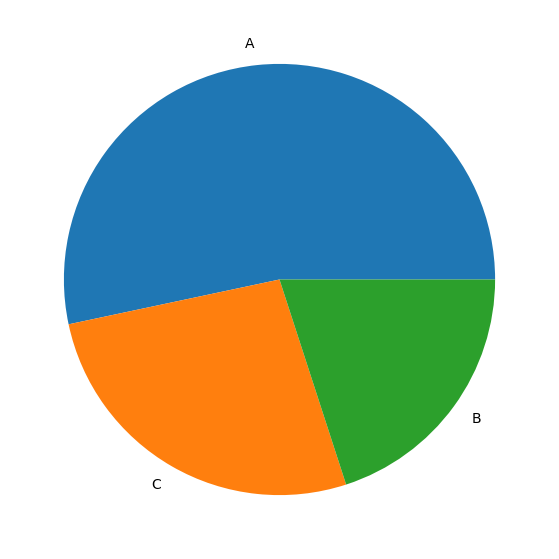

In [25]:
#The final phase applies our data classifications directly to physical warehouse logistics. 
#We map each item to its current physical zone. Under lean warehouse principles, Class A items belong in prime locations near the shipping dock (Zone A), while Class C items belong in the deep back (Zone C). 
#By applying a relational logic filter (`!=`), we isolate the exact products stored in the wrong zones and dynamically generate a **Floor Manager Relocation List** to reduce worker travel time and save labor costs.

class_counts = df['ABC_Class'].value_counts()
fig = plt.figure(figsize=(10, 7)) 
plt.pie(class_counts, labels=class_counts.index)
print(class_counts)

In [26]:
#plt.pie(class_counts)
plt.show()

In [27]:
df['Current_Location'] = ['C', 'A', 'B', 'A', 'C', 'B', 'A', 'C', 'B', 'A', 'C', 'B', 'A', 'C', 'B']
print(df[['Product_Name', 'ABC_Class', 'Current_Location']].head(10))

                Product_Name ABC_Class Current_Location
0   Premium Forklift Battery         A                C
1      Industrial Steel Rack         A                A
3     Standard Wooden Pallet         A                B
7        LED Warehouse Light         A                A
12    Shipping Labels (Roll)         A                C
4      Cardboard Box - Large         A                B
10  Barcode Scanner Handheld         A                A
2     Heavy Duty Pallet Jack         A                C
5          Stretch Wrap Roll         B                B
6      Packing Tape (6 Pack)         B                A


In [28]:
mismatched_items = df[df['ABC_Class'] != df['Current_Location']]
print(mismatched_items[['Product_Name', 'ABC_Class', 'Current_Location']])

                Product_Name ABC_Class Current_Location
0   Premium Forklift Battery         A                C
3     Standard Wooden Pallet         A                B
12    Shipping Labels (Roll)         A                C
4      Cardboard Box - Large         A                B
2     Heavy Duty Pallet Jack         A                C
6      Packing Tape (6 Pack)         B                A
8     Safety Vest - High Vis         B                C
11     Thermal Label Printer         C                B
9      Steel Toe Boot Covers         C                A
14          Heavy Duty Broom         C                B
